# 04 — Avaliação e Interpretação

Aqui a análise deixa de ser técnica e passa a ser de negócio.

**Contexto.** A base trata de clientes de crédito; a variável-alvo (`TARGET`) vale 1 para **mau pagador** (616 de 36.457 registros, 1,69%). No notebook 03 foram comparados quatro modelos por validação cruzada (agrupada por `PROFILE_ID`). O **XGBoost** foi o melhor em ROC-AUC (0,621) e em PR-AUC (0,106, mais de 6× o acaso) e é o modelo avaliado aqui.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

PROCESSED = Path("..") / "data" / "processed"
DATA = PROCESSED / "dataset_tratado.csv"
TARGET = "TARGET"        # variável alvo: 1 = mau pagador
GRUPO = "PROFILE_ID"     # mesmo perfil nunca fica em treino e teste ao mesmo tempo

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


def br(valor, fmt=".3f"):
    # Formata número no padrão brasileiro (vírgula decimal, ponto de milhar)
    return format(valor, fmt).translate({ord(","): ".", ord("."): ","})

## 0. Modelo escolhido e conjunto de teste

O notebook 03 só fez validação cruzada e não guardou um conjunto de teste. Para avaliar o modelo de forma independente, este notebook:

1. repete **exatamente** o esquema de divisão do 03 (`StratifiedGroupKFold`, 5 partes, mesma semente) e reserva a **primeira parte (≈ 20% dos perfis)** como **teste**, nunca visto no treino;
2. treina o XGBoost, com os mesmos hiperparâmetros do 03, apenas nos 80% restantes.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

df = pd.read_csv(DATA)

# ID e PROFILE_ID são identificadores, não preditores (igual ao notebook 03)
X = df.drop(columns=["ID", GRUPO, TARGET])
y = df[TARGET]
grupos = df[GRUPO]

colunas_num = X.select_dtypes("number").columns.tolist()
colunas_cat = X.select_dtypes(exclude="number").columns.tolist()

# Mesma divisão do notebook 03; a 1ª parte vira o teste
skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
idx_treino, idx_teste = next(skf.split(X, y, groups=grupos))

X_train, X_test = X.iloc[idx_treino], X.iloc[idx_teste]
y_train, y_test = y.iloc[idx_treino], y.iloc[idx_teste]
g_test = grupos.iloc[idx_teste].to_numpy()

# Garantia contra vazamento: nenhum perfil nos dois lados
assert set(grupos.iloc[idx_treino]).isdisjoint(set(g_test))

# Mesmo pipeline e hiperparâmetros do XGBoost no notebook 03
modelo = Pipeline([
    ("prep", ColumnTransformer([
        ("num", "passthrough", colunas_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), colunas_cat),
    ])),
    ("clf", XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.2,
        subsample=0.8, colsample_bytree=0.6,
        eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1,
    )),
])
modelo.fit(X_train, y_train)

proba = modelo.predict_proba(X_test)[:, 1]   # probabilidade de ser mau pagador

print(f"Treino: {len(X_train):,} linhas | {int(y_train.sum())} maus pagadores ({y_train.mean():.2%})")
print(f"Teste : {len(X_test):,} linhas | {int(y_test.sum())} maus pagadores ({y_test.mean():.2%})")

Treino: 29,165 linhas | 492 maus pagadores (1.69%)
Teste : 7,292 linhas | 124 maus pagadores (1.70%)


## 1. Métricas no conjunto de teste

Acurácia sozinha engana em base desbalanceada.

,teste,IC 95% (inf),IC 95% (sup),acaso,validação cruzada (nb 03)
ROC-AUC,0.603,0.537,0.674,0.500,0.621
PR-AUC,0.102,0.053,0.163,0.017,0.106



Relatório de classificação no corte padrão (probabilidade ≥ 0,50):
              precision    recall  f1-score   support

 bom pagador      0.984     1.000     0.992      7168
 mau pagador      0.889     0.065     0.120       124

    accuracy                          0.984      7292
   macro avg      0.936     0.532     0.556      7292
weighted avg      0.982     0.984     0.977      7292



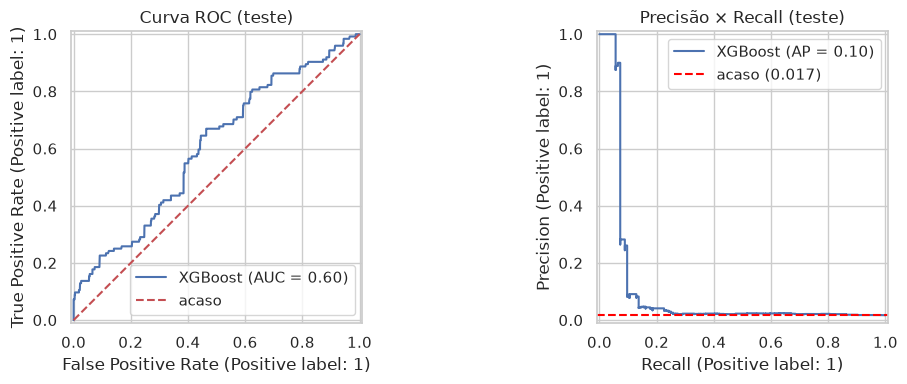

In [10]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay,
    PrecisionRecallDisplay, average_precision_score, confusion_matrix,
)

roc_teste = roc_auc_score(y_test, proba)
pr_teste = average_precision_score(y_test, proba)
prevalencia = y_test.mean()

# Intervalo de confiança por bootstrap SOBRE PERFIS (não sobre linhas), porque
# linhas do mesmo perfil são quase cópias e inflariam a confiança.
rng = np.random.default_rng(RANDOM_STATE)
y_arr = y_test.to_numpy()
pos_por_grupo = pd.Series(np.arange(len(y_arr))).groupby(g_test).apply(np.array)
perfis = pos_por_grupo.index.to_numpy()

boot_roc, boot_pr = [], []
for _ in range(300):
    sorteio = rng.choice(perfis, size=len(perfis), replace=True)
    ix = np.concatenate(pos_por_grupo.loc[sorteio].to_list())
    if y_arr[ix].sum() == 0:
        continue
    boot_roc.append(roc_auc_score(y_arr[ix], proba[ix]))
    boot_pr.append(average_precision_score(y_arr[ix], proba[ix]))

ic_roc = np.percentile(boot_roc, [2.5, 97.5])
ic_pr = np.percentile(boot_pr, [2.5, 97.5])

tabela_metricas = pd.DataFrame({
    "teste": [roc_teste, pr_teste],
    "IC 95% (inf)": [ic_roc[0], ic_pr[0]],
    "IC 95% (sup)": [ic_roc[1], ic_pr[1]],
    "acaso": [0.5, prevalencia],
    "validação cruzada (nb 03)": [0.621, 0.106],
}, index=["ROC-AUC", "PR-AUC"]).round(3)
display(tabela_metricas)

print("\nRelatório de classificação no corte padrão (probabilidade ≥ 0,50):")
print(classification_report(y_test, (proba >= 0.5).astype(int),
                            target_names=["bom pagador", "mau pagador"], digits=3, zero_division=0))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[0], name="XGBoost")
ax[0].plot([0, 1], [0, 1], "r--", label="acaso")
ax[0].set_title("Curva ROC (teste)")
ax[0].legend()
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=ax[1], name="XGBoost")
ax[1].axhline(prevalencia, color="red", ls="--", label=f"acaso ({prevalencia:.3f})")
ax[1].set_title("Precisão × Recall (teste)")
ax[1].legend()
plt.tight_layout()
plt.show()

Leitura: no teste, o XGBoost obtém **ROC-AUC 0,603** (IC 95%: 0,537–0,674) e **PR-AUC 0,102** (IC 95%: 0,053–0,163), contra 0,017 de um modelo ao acaso. Ou seja, a precisão média do ranking é **6,0× a do acaso**. O intervalo é largo porque o teste tem apenas 124 maus pagadores; por isso os números devem ser lidos como ordem de grandeza, não como valor exato.

Este teste coincide com a 1ª parte da validação cruzada do notebook 03, uma das cinco que formam a média (ROC-AUC 0,621; PR-AUC 0,106), então diferenças em relação a ela são esperadas.

## 2. Justificativa das métricas

**Por que não acurácia.**
Apenas 1,7% dos clientes são maus pagadores (cerca de 1 em cada 58). Um "modelo" que aprove todos os clientes acerta 98,3% das vezes sem identificar nenhum incumpridor. A tabela de classificação comprova exatamente isso: a acurácia do modelo é altíssima (98,4%), mas o seu *recall* para a classe de maus pagadores é de apenas 0,065 (6,5%). Ou seja, a acurácia alta, neste cenário, esconde a ineficácia do modelo.

**Métricas usadas.**

* **ROC-AUC:** Mede se o modelo coloca os maus pagadores acima dos bons na fila de risco, independentemente do corte (threshold). Vale 0,5 se for puro acaso.


* **PR-AUC (Precisão × Recall):** Foca-se apenas na classe rara. Responde à pergunta: *quando o modelo sinaliza um risco, com que frequência acerta, e quantos dos maus ele encontra?* É a métrica mais honesta, pois o limite base de acaso é de apenas 0,017. O valor obtido pelo modelo foi de 0,102, o que, apesar de parecer baixo, é muito superior ao aleatório.


* **Recall e precisão num corte operacional:** Traduzem o modelo em decisão real: quantos maus pagadores apanhamos (recall) e quantos bons clientes incomodamos para isso (precisão).

**Qual erro custa mais caro?**

* **Falso negativo** (cliente mau classificado como bom): A empresa concede crédito e perde o valor emprestado. É o erro com o **maior custo unitário** (por ocorrência).
* **Falso positivo** (cliente bom classificado como mau): A empresa recusa ou restringe um cliente que pagaria, perdendo a margem do negócio. Custa menos por ocorrência, mas como **existem cerca de 58 bons clientes para cada mau pagador**, o volume de falsos positivos cresce de forma explosiva ao tentar apanhar mais incumpridores. O gráfico de Precisão × Recall ilustra perfeitamente este fenómeno: ao tentarmos aumentar o *recall* (apanhar mais maus pagadores), a precisão cai quase verticalmente para valores próximos de zero, inundando a operação com falsos alarmes.



O equilíbrio final dependerá de quanto custa um calote *em relação* à margem de lucro de um bom cliente.

## 3. Matriz de confusão

Duas visões lado a lado:

- **Corte padrão (0,50):** o modelo calcula, para cada cliente, uma probabilidade de ser mau pagador, entre 0 e 1. Para transformar essa probabilidade em uma resposta de "bom" ou "mau", é preciso definir um corte. O padrão das bibliotecas, e o que o notebook 03 usou para calcular recall e F1, é 0,50: quem tem probabilidade igual ou superior a 50% é classificado como mau pagador, e os demais como bons pagadores. Esse corte funciona bem quando as duas classes têm tamanhos parecidos, mas aqui apenas 1,7% dos clientes são maus pagadores. Mesmo os clientes que o modelo considera mais arriscados costumam receber probabilidades de poucos pontos percentuais, muito abaixo de 50%, e por isso quase ninguém é sinalizado. O resultado é um recall muito baixo, que não reflete a capacidade do modelo de ordenar os clientes por risco.


- **Corte operacional:** em vez de fixar uma probabilidade arbitrária, como 0,50, parte-se de uma pergunta prática: *quantos clientes a empresa consegue tratar com mais cautela?* "Tratar com mais cautela" significa aplicar uma ação mais rigorosa aos clientes de maior risco, como análise manual da proposta, pedido de comprovação adicional ou limite de crédito inicial menor. Essa capacidade é definida como um percentual da base (aqui, 10%, ajustável em `TAXA_ALTO_RISCO`).

  O funcionamento é este: os clientes são ordenados da maior para a menor probabilidade de ser mau pagador, e o corte é a probabilidade do cliente que fica na fronteira desse grupo. Quem está acima dele entra na fila de alto risco; quem está abaixo segue o fluxo normal. Por exemplo, se o cliente na posição dos 10% mais arriscados tem probabilidade de 2,4%, o corte é 2,4%, e todos com probabilidade igual ou superior a ela são sinalizados.

  Para definir o corte, usa-se apenas a ordem das probabilidades, nunca a informação real de quem pagou ou não (o rótulo bom/mau). Os rótulos só entram depois, para medir o resultado: quantos maus pagadores a fila encontrou e quantos bons clientes foram sinalizados junto.

Corte operacional (sinaliza os 10% mais arriscados): probabilidade ≥ 0.024


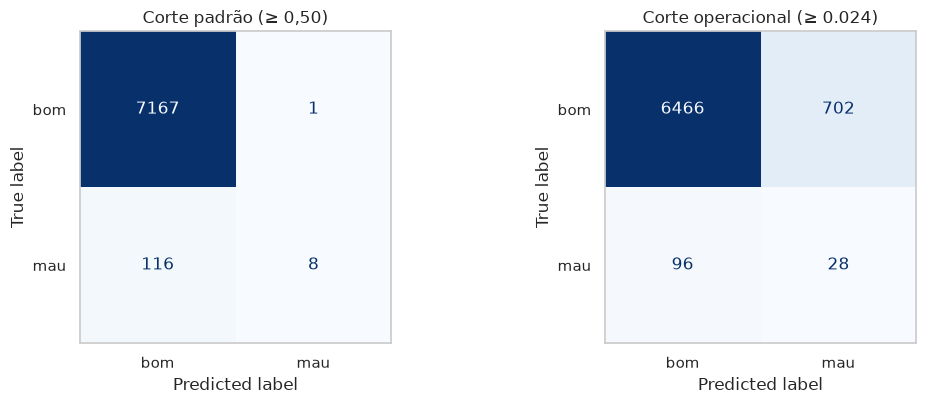

In [11]:
# ---- PARÂMETRO DE NEGÓCIO: fração dos clientes que a empresa consegue tratar
#      como "alto risco" (ex.: fila de análise manual). Ajuste conforme a capacidade real.
TAXA_ALTO_RISCO = 0.10

corte_op = float(np.quantile(proba, 1 - TAXA_ALTO_RISCO))
print(f"Corte operacional (sinaliza os {TAXA_ALTO_RISCO:.0%} mais arriscados): probabilidade ≥ {corte_op:.3f}")

pred_05 = (proba >= 0.5).astype(int)
pred_op = (proba >= corte_op).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, pred, titulo in [
    (ax[0], pred_05, "Corte padrão (≥ 0,50)"),
    (ax[1], pred_op, f"Corte operacional (≥ {corte_op:.3f})"),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=["bom", "mau"], cmap="Blues", colorbar=False, ax=a)
    a.set_title(titulo)
    a.grid(False)
plt.tight_layout()
plt.show()

tn5, fp5, fn5, tp5 = confusion_matrix(y_test, pred_05).ravel()
tno, fpo, fno, tpo = confusion_matrix(y_test, pred_op).ravel()


Leitura:

Cada quadrado conta quantos clientes caíram em cada situação (as linhas são a realidade e as colunas são o que o modelo previu):

- **Canto superior esquerdo (bom → bom):** bons clientes que o modelo deixou passar. É o acerto "sem alarme".
- **Canto superior direito (bom → mau):** bons clientes sinalizados por engano. São os *falsos alarmes*.
- **Canto inferior esquerdo (mau → bom):** maus pagadores que o modelo deixou passar. É o erro mais caro, porque o calote acontece.
- **Canto inferior direito (mau → mau):** maus pagadores que o modelo encontrou. É o acerto que interessa.

**Corte padrão (0,50).** O modelo sinalizou apenas 9 clientes. Desses, 8 eram de fato maus pagadores, ou seja, quase não erra quando sinaliza. Mas ele deixou passar **116 dos 124 maus pagadores**, e só encontrou **6,5%** deles. Na prática, não serve para triagem, porque quase ninguém atinge 50% de probabilidade.

**Corte operacional (10% mais arriscados).** Aqui o modelo sinalizou 730 clientes, e **28 eram maus pagadores (22,6% do total)**. Em troca, **702 bons clientes** entraram na fila por engano.

**Comparando os dois:**

| | Corte 0,50 | Corte operacional |
|---|---|---|
| Clientes sinalizados | 9 | 730 |
| Maus pagadores encontrados | 8 de 124 (6,5%) | 28 de 124 (22,6%) |
| Maus pagadores que passaram | 116 | 96 |
| Bons clientes sinalizados por engano | 1 | 702 |
| Acerto entre os sinalizados | 89% | 3,8% |

**O que isso significa.** Para encontrar 20 maus pagadores a mais (de 8 para 28), a empresa aceita sinalizar cerca de 700 bons clientes a mais. Entre os sinalizados, 3,8% são maus pagadores, contra 1,7% na população geral, ou seja, **2,2 vezes mais** do que escolher clientes ao acaso (que encontraria cerca de 12 maus pagadores em 730 clientes, e não 28). O modelo concentra o risco, mas ainda erra muito: para cada mau pagador encontrado, cerca de 25 bons clientes entram na fila. Por isso o corte operacional só faz sentido com ações leves, como análise manual ou limite menor, e não com recusa automática.

### 3.1 Quanto vale cada corte? (tabela de decisão)

A tabela mostra o que acontece conforme a empresa aumenta a fila de alto risco: mais maus pagadores encontrados, mas também muito mais bons clientes incomodados.

A coluna **saldo** é uma **simulação ilustrativa**, não um resultado real. Ela assume uma hipótese de custo que **deve ser substituída pelo número da área financeira**: um calote custa `PERDA_CALOTE` vezes a margem que se ganha com um bom cliente. Se a ação sobre o sinalizado for "recusar", cada mau barrado evita a perda e cada bom barrado custa uma margem. Ações mais leves (revisão manual, limite menor) têm custo menor por falso positivo e ficam mais vantajosas.

In [ ]:
# ---- HIPÓTESE ILUSTRATIVA: perda de um calote, medida em "margens de um bom cliente".
#      SUBSTITUIR pelo valor real informado pela área de crédito/financeira.
PERDA_CALOTE = 10

taxas = sorted({0.02, 0.05, 0.10, 0.20, 0.30, TAXA_ALTO_RISCO})
linhas = []
for t in taxas:
    c = float(np.quantile(proba, 1 - t))
    p = (proba >= c).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    linhas.append({
        "% sinalizados (alvo)": f"{t:.0%}",
        "corte (prob.)": round(c, 3),
        "clientes sinalizados": tp + fp,
        "maus encontrados": tp,
        "recall": tp / (tp + fn),
        "precisão": tp / max(tp + fp, 1),
        "ganho vs. acaso (lift)": (tp / max(tp + fp, 1)) / prevalencia,
        "bons sinalizados por mau achado": np.round((fp / tp),1) if tp else np.nan,
        "saldo por 1.000 clientes*": ((tp * PERDA_CALOTE - fp) / len(y_test) * 1000),
    })
tabela_corte = pd.DataFrame(linhas).set_index("% sinalizados (alvo)")
display(tabela_corte.round(3))

ponto_equilibrio = 1 / (1 + PERDA_CALOTE)
print(f"* saldo = (maus evitados × {PERDA_CALOTE}) − (bons barrados × 1), em margens de bom cliente.")
print(f"Ponto de equilíbrio: recusar só compensa se a precisão do corte for maior que {br(ponto_equilibrio, '.1%')} "
      f"(com perda de calote = {PERDA_CALOTE}× a margem).")

,corte (prob.),clientes sinalizados,maus encontrados,recall,precisão,ganho vs. acaso (lift),bons sinalizados por mau achado,saldo por 1.000 clientes*
% sinalizados (alvo),,,,,,,,
2%,0.083,146,12,0.097,0.082,4.833,11.2,-1.920
5%,0.040,365,17,0.137,0.047,2.739,20.5,-24.410
10%,0.024,730,28,0.226,0.038,2.256,25.1,-57.872
20%,0.012,1468,32,0.258,0.022,1.282,44.9,-153.044
30%,0.007,2193,50,0.403,0.023,1.341,42.9,-225.315


* saldo = (maus evitados × 10) − (bons barrados × 1), em margens de bom cliente.
Ponto de equilíbrio: recusar só compensa se a precisão do corte for maior que 9,1% (com perda de calote = 10× a margem).


**Leitura: vale a pena usar o modelo para recusar clientes?**

**A pergunta.** Se o banco passar a recusar os clientes que o modelo considera mais arriscados, ele evita alguns calotes, mas também deixa de ganhar com bons clientes recusados por engano. A tabela acima compara, para diferentes tamanhos de "fila de risco", o que se ganha e o que se perde.

**Como ler a tabela (exemplo com a fila de 2%).** De cada 100 clientes que o modelo sinaliza como mais arriscados, cerca de 8 são de fato maus pagadores (coluna *precisão*: 8,2%), e os outros 92 são bons clientes. Isso é 4,8 vezes mais maus pagadores do que numa escolha ao acaso (*ganho vs. acaso*), então o modelo realmente ajuda a concentrar o risco. Mas, para cada mau pagador encontrado, cerca de 11 bons clientes são sinalizados junto.

**O cálculo financeiro.** Para saber se compensa recusar, é preciso comparar o que se evita com o que se perde:

- Cada mau pagador recusado **evita um prejuízo**, que assumimos, de forma ilustrativa, ser **10 vezes** o lucro obtido com um bom cliente;
- Cada bom cliente recusado por engano **custa o lucro desse cliente** (1 unidade).

Com esses valores, o ponto de equilíbrio é uma precisão de **9,1%**: só vale recusar se, entre os sinalizados, mais de 9 em cada 100 forem maus pagadores. A coluna *saldo* mostra o resultado por 1.000 clientes analisados, em unidades de lucro de um bom cliente.

**O resultado.**

| Fila de risco | Maus pagadores entre os sinalizados | Maus pagadores encontrados (do total) | Saldo por 1.000 clientes |
|---|---|---|---|
| 2% dos clientes | 8,2% | 9,7% | −1,9 |
| 5% | 4,7% | 13,7% | −24,4 |
| 10% | 3,8% | 22,6% | −57,9 |
| 20% | 2,2% | 25,8% | −153,0 |
| 30% | 2,3% | 40,3% | −225,3 |

**Nenhuma das filas compensa se a ação for recusar o crédito.** Quanto maior a fila, mais maus pagadores são encontrados, mas muito mais bons clientes são recusados por engano, e o saldo piora.

**A fila de 2% é a única perto do equilíbrio** (8,2% de precisão, contra os 9,1% necessários). Ela passaria a compensar se o prejuízo de um calote fosse cerca de 11 vezes o lucro de um bom cliente, em vez de 10. Como esse custo é uma hipótese, e o teste tem poucos casos (12 maus pagadores nessa fila), esse ponto merece ser validado com os números reais do banco.

**O que isso significa para a decisão.**

1. **O modelo não deve ser usado para recusar crédito automaticamente.** Ele ordena os clientes melhor do que o acaso, mas erra demais para justificar a recusa.
2. **Ele pode ser útil para priorizar o trabalho da equipe.** Em vez de recusar, o banco pode usar o modelo para decidir quais propostas passam por análise manual, quais pedem comprovação adicional de renda ou quais começam com limite menor. Essas ações custam menos do que perder o cliente, então um erro com um bom cliente sai mais barato. Se compensam de fato depende do custo real de cada ação, que a simulação ainda não inclui.
3. **O custo do calote é a peça que falta.** O banco precisa informar quanto, em média, um calote custa em relação ao lucro de um bom cliente. Com esse número, o cálculo deixa de ser ilustrativo e passa a indicar o tamanho ideal da fila.

**Cautela.** Esses resultados vêm de uma amostra de teste pequena (124 maus pagadores) e de um custo assumido. Devem ser lidos como um método de decisão, não como números finais.

## 4. Importância das variáveis

Usa-se **importância por permutação** no conjunto de teste: embaralha-se uma variável por vez e mede-se quanto a PR-AUC cai. Quanto maior a queda, mais o modelo dependia daquela variável. Valores próximos de zero (ou negativos) indicam que a variável não ajuda de forma confiável.

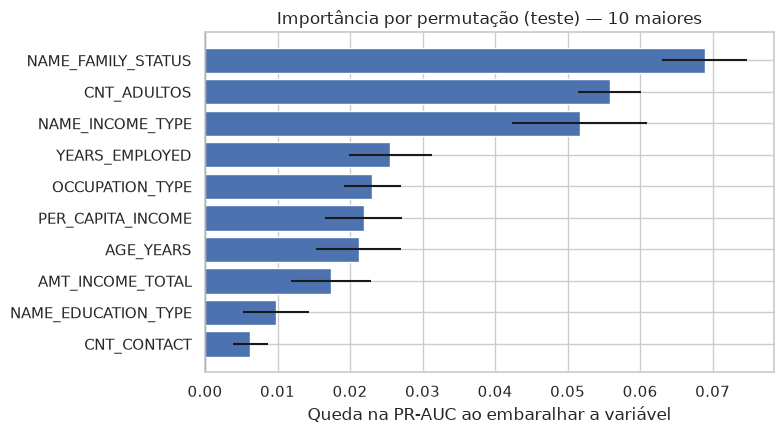

,queda_pr_auc,desvio
NAME_FAMILY_STATUS,0.0689,0.0058
CNT_ADULTOS,0.0558,0.0044
NAME_INCOME_TYPE,0.0517,0.0093
YEARS_EMPLOYED,0.0256,0.0058
OCCUPATION_TYPE,0.0230,0.0039
PER_CAPITA_INCOME,0.0219,0.0053
AGE_YEARS,0.0212,0.0059
AMT_INCOME_TOTAL,0.0174,0.0055
NAME_EDUCATION_TYPE,0.0098,0.0046
CNT_CONTACT,0.0062,0.0024


In [13]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    modelo, X_test, y_test,
    scoring="average_precision", n_repeats=10,
    random_state=RANDOM_STATE, n_jobs=1,
)
imp = pd.DataFrame({
    "queda_pr_auc": perm.importances_mean,
    "desvio": perm.importances_std,
}, index=X_test.columns).sort_values("queda_pr_auc", ascending=False)

top = imp.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top.index, top["queda_pr_auc"], xerr=top["desvio"], color="#4C72B0")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Queda na PR-AUC ao embaralhar a variável")
ax.set_title("Importância por permutação (teste) — 10 maiores")
plt.tight_layout()
plt.show()

display(imp.round(4))

### 4.1 Em que direção cada variável pesa?

As cinco características com maior peso são: **estado civil, número de adultos na família, tipo de renda, tempo de emprego e ocupação**. Elas respondem por cerca de **68%** de toda a contribuição das variáveis úteis, e o estado civil sozinho por **21%**. Ou seja, o modelo se apoia em poucas informações cadastrais, e nenhuma delas é decisiva sozinha.

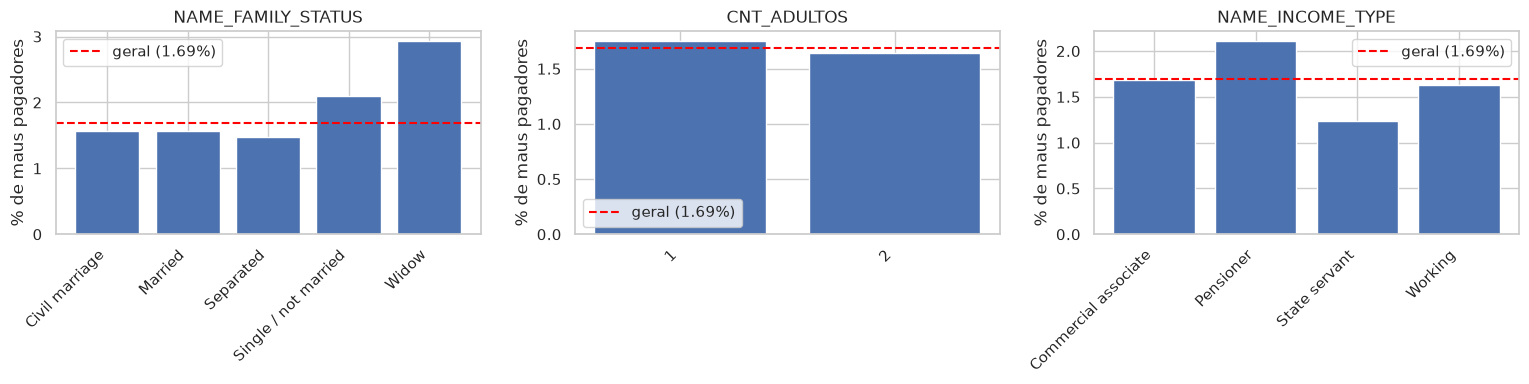

In [14]:
variaveis_top = imp.head(3).index.tolist()
taxa_geral = df[TARGET].mean()
MIN_N = 100   # ignora categorias muito pequenas (taxa instável)

fig, axes = plt.subplots(1, len(variaveis_top), figsize=(5.2 * len(variaveis_top), 4))
for a, col in zip(np.atleast_1d(axes), variaveis_top):
    serie = df[col]
    if serie.dtype.kind in "if" and serie.nunique() > 10:
        faixa = pd.qcut(serie, 5, duplicates="drop")
    else:
        faixa = serie
    t = df.groupby(faixa, observed=True)[TARGET].agg(["mean", "size"])
    t = t[t["size"] >= MIN_N]
    a.bar(t.index.astype(str), t["mean"] * 100, color="#4C72B0")
    a.axhline(taxa_geral * 100, color="red", ls="--", label=f"geral ({taxa_geral:.2%})")
    a.set_title(col)
    a.set_ylabel("% de maus pagadores")
    a.tick_params(axis="x", rotation=45)
    for lbl in a.get_xticklabels():
        lbl.set_ha("right")
    a.legend()
plt.tight_layout()
plt.show()

**Como o risco varia (gráficos acima).** A linha vermelha é a taxa média de maus pagadores da base (1,7%):

| Característica | Grupos com mais risco | Grupos com menos risco |
|---|---|---|
| Estado civil | Viúvos (cerca de 2,9%) e solteiros (cerca de 2,1%) | Casados, união civil e separados (cerca de 1,5%) |
| Tipo de renda | Pensionistas (cerca de 2,1%) | Servidores públicos (cerca de 1,2%) |
| Número de adultos | Quase sem diferença (cerca de 1,75% com 1 adulto e 1,65% com 2) | |

**Pontos de atenção para a decisão.**

1. **As diferenças são modestas.** O grupo de maior risco (viúvos) tem cerca de 2,9% de maus pagadores, contra 1,5% do grupo de menor risco. Ainda é um risco baixo, só que em torno do dobro. Estas características ajudam a ordenar os clientes, mas nenhuma separa sozinha bons e maus pagadores.
2. **"Número de adultos" merece cautela.** Ele aparece como a segunda característica mais importante, mas o gráfico mostra quase nenhuma diferença de risco entre os grupos. Isso pode indicar que o modelo usa essa informação combinada com outras, ou que é efeito de ruído, já que o teste tem poucos maus pagadores. Antes de usá-la em qualquer regra de negócio, convém investigar.
3. **Os gráficos descrevem associação, não causa.** Não é correto concluir que "ser viúvo causa inadimplência". O padrão pode refletir outras características, como idade ou renda.
4. **Poucos casos em alguns grupos.** Os viúvos, por exemplo, são cerca de 1.500 clientes na base. Taxas calculadas com poucos casos oscilam bastante.

**Conformidade (Jurídico e Compliance).** Estado civil é uma característica pessoal e a que mais pesa no modelo. Antes de usá-lo em decisão de crédito, é preciso validar com Jurídico e Compliance se esse uso é permitido e avaliar o risco de tratamento discriminatório. Um ponto favorável: o **gênero não ajuda o modelo de forma confiável** (importância nula ou negativa), então ele não depende dessa informação.

## 5. Implicações práticas

### Números-chave: o que o modelo entrega na prática

**1. O problema é raro.** Apenas cerca de **1 em cada 59 clientes (1,7%)** é mau pagador. Em uma carteira de 7.292 clientes, isso dá 124 maus pagadores perdidos no meio de mais de 7.000 bons clientes.

**2. O que acontece se olharmos com mais atenção os 10% de maior risco.** Suponha que a equipe consiga analisar com atenção redobrada 730 clientes (10% da carteira):

- **Escolhendo ao acaso**, a equipe encontraria cerca de **12 maus pagadores**, porque 10% dos clientes contêm cerca de 10% dos maus.
- **Usando o modelo** para escolher quem analisar, a equipe encontra **28 maus pagadores (23% do total)**. É **mais que o dobro** do que o acaso entregaria.

**3. Quão "pura" é essa lista.** Na lista de 730 clientes sinalizados, **3,8% são de fato maus pagadores**, ou seja, cerca de 4 em cada 100. Na população geral, são 1,7%, então a lista concentra **2,3 vezes mais risco** do que a média. Os outros **96 em cada 100** clientes da lista são bons pagadores.

**4. O preço dessa lista.** Para encontrar cada mau pagador, a equipe precisa analisar cerca de **25 bons clientes junto**. Dos 730 sinalizados, 28 são maus e 702 são bons.

**5. O que isso significa para a decisão.** O modelo **ajuda a priorizar**, porque encontra mais maus pagadores do que o acaso, mas **erra muito para decidir sozinho**: a maioria dos sinalizados (96%) é de bons clientes, e ainda restam **96 maus pagadores fora da lista**, que passariam sem ser notados. Por isso, a melhor forma de usá-lo é para direcionar o trabalho de análise (revisão manual, comprovação de renda, limite inicial menor), e não para recusar crédito automaticamente.

### O que a empresa deve fazer de diferente

1. **Usar o modelo para priorizar, não para decidir.** O poder de separação é modesto (ROC-AUC ≈ 0,62). Ele serve para ordenar a fila e dizer "quem olhar primeiro", e não para aprovar ou negar crédito automaticamente. Recusar com base apenas no score barraria muitos bons clientes.

2. **Criar faixas de risco com ações proporcionais.** Em vez de "aprova / nega", usar três degraus: *risco normal* (fluxo atual), *risco elevado* (análise manual, pedido de comprovação adicional, limite inicial menor) e *risco muito alto* (somente o topo da lista; usar a faixa em que a tabela da seção 3.1 mostrar o maior ganho sobre o acaso). Quanto mais leve a ação, menor o custo de errar com um bom cliente.

3. **Dimensionar a fila pela capacidade da equipe.** A tabela da seção 3.1 mostra o preço de cada escolha: aumentar a fila encontra mais maus pagadores, mas incomoda muito mais bons clientes. O percentual ideal é uma decisão de negócio que combina capacidade da equipe de análise e custo de um calote. Esse custo precisa ser informado pela área financeira: a simulação usa um valor ilustrativo.

4. **Não confiar em "98% de acerto".** Qualquer relatório que cite acurácia para este modelo deve ser descartado: um sistema que aprova todos também tem 98%.

5. **Testar antes de escalar.** Rodar o modelo em paralelo à política atual (sem alterar decisões) por alguns meses, medir quantos dos sinalizados realmente viram inadimplentes e só então ligar as ações. Acompanhar mensalmente, porque o perfil dos clientes muda e o desempenho pode cair.

6. **Cuidar das variáveis pessoais.** Se gênero, idade ou estado civil estiverem entre os fatores de peso, avaliar com Jurídico/Compliance antes de usá-los em decisão de crédito, e testar se o modelo mantém desempenho parecido sem elas.

**Mensagem em uma frase:** o modelo pode ajudar como *filtro de atenção*, concentrando o esforço de análise nos clientes mais arriscados, desde que a tabela da seção 3.1 confirme ganho sobre o acaso no corte escolhido; ele ainda não é um *decisor* de crédito.

## 6. Limitações

**Onde o modelo falha**

- **Poder de separação modesto.** ROC-AUC de 0,62 na validação cruzada: bem acima do acaso (0,5), mas longe do que se espera de um modelo de decisão automática. No corte padrão (0,50), o recall é de apenas ≈ 5%.
- **Muitos falsos alarmes.** Como só 1,7% são maus pagadores, qualquer fila de risco é composta majoritariamente por bons clientes (ver "bons sinalizados por mau achado").
- **Resultado instável.** O desvio da PR-AUC entre as partes da validação cruzada foi alto (≈ 0,03 sobre uma média de 0,106), e o teste tem poucos maus pagadores (≈ 123). Os intervalos de confiança da seção 1 são largos: os números têm margem de erro grande.

**Limitações da base e do método**

- **Poucas informações sobre o cliente.** As variáveis são cadastrais (renda, ocupação, família, moradia). Não há histórico de pagamento, relacionamento anterior ou dados de bureau (empresas que reunem informações do comportamento financeiro das pessoas, como Serasa e SPC), justamente os sinais que costumam mais separar bons e maus pagadores.
- **Linhas repetidas por perfil.** São 36.457 linhas para 9.728 perfis. A validação foi agrupada por perfil para evitar vazamento, mas o número efetivo de clientes independentes é bem menor do que o de linhas.
- **Hiperparâmetros fixos.** O XGBoost foi usado com valores manuais, sem busca de otimização. Existe margem de ganho, embora a base limite o teto.
- **Importância não é causa.** O gráfico de importância e as taxas por faixa descrevem associações; não provam que mudar uma variável mude o risco.
- **Custo hipotético.** A simulação financeira da seção 3.1 usa um custo ilustrativo de calote. Os valores reais podem inverter a conclusão.
- **Sem validação no tempo.** O teste é uma amostra aleatória de perfis, não um período futuro. Em produção, mudança de perfil dos clientes ou da economia pode reduzir o desempenho.

**O que eu faria com mais tempo ou mais dados**

1. Incluir histórico de pagamento e dados de bureau, a mudança com maior potencial de ganho.
2. Fazer busca de hiperparâmetros e comparar com modelos mais regularizados, medindo ganho real contra o ruído da validação.
3. Calibrar as probabilidades e escolher o corte com os custos reais (calote, margem, custo da análise manual).
4. Validar fora do tempo (treinar no passado, testar em período posterior) e rodar um piloto em paralelo.
5. Auditar justiça: comparar taxas de sinalização e erros entre grupos (gênero, faixa etária) e testar o modelo sem variáveis pessoais.